In [45]:
import torch

In [10]:
import json, re, torch
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats


pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_colwidth", 50)


def count_params(run_dir: Path) -> int | None:
    ckpt = run_dir / "best_model.pt"
    if not ckpt.exists():
        return None
    state = torch.load(ckpt, map_location="cpu")
    if isinstance(state, dict) and "state_dict" in state:
        state = state["state_dict"]
    elif isinstance(state, dict) and "model_state_dict" in state:
        state = state["model_state_dict"]
    if isinstance(state, dict):
        return sum(p.numel() for p in state.values() if isinstance(p, torch.Tensor))
    return sum(p.numel() for p in state.parameters())

def load_training_time(run_dir: Path) -> dict:
    p = run_dir / "training_time.json"
    if not p.exists():
        return {}
    return json.loads(p.read_text())


def load_best_epoch_metrics(run_dir: Path) -> dict:
    p = run_dir / "history.json"
    if not p.exists():
        return {}
    h = json.loads(p.read_text())
    val_f1 = h.get("val_f1_macro", [])
    val_acc = h.get("val_accuracy", [])
    if not val_f1:
        return {}
    best_epoch = int(np.argmax(val_f1))

    # проверка: число эпох в history vs training_time.json
    actual_epochs = len(val_f1)
    time_data = json.loads((run_dir / "training_time.json").read_text()) \
        if (run_dir / "training_time.json").exists() else {}
    reported_epochs = time_data.get("epochs")
    mismatch = (
        reported_epochs is not None and actual_epochs != reported_epochs
    )

    return {
        "best_epoch":      best_epoch,
        "val_f1_best":     val_f1[best_epoch],
        "val_acc_best":    val_acc[best_epoch] if val_acc else None,
        "actual_epochs":   actual_epochs,
        "reported_epochs": reported_epochs,
        "epoch_mismatch":  mismatch,
    }


def load_metrics_df(runs_dir: Path, dataset: str = "") -> pd.DataFrame:
    records = []
    for p in sorted(runs_dir.glob("*/test_metrics.json")):
        run = p.parent.name
        run_dir = runs_dir / run
        data = json.loads(p.read_text())
        m = re.match(r"^(.+?)_w\d+_s\d+_seed\d+(.*)$", run)
        model   = m.group(1)              if m else run
        variant = m.group(2).lstrip("_") or "base" if m else "base"

        time_data = load_training_time(run_dir)
        best_data = load_best_epoch_metrics(run_dir)

        records.append({
            "dataset":        dataset,
            "run":            run,
            "model":          model,
            "variant":        variant,
            "accuracy":       data.get("accuracy"),
            "f1_macro":       data.get("f1_macro"),
            "n_params":       count_params(run_dir),
            "best_epoch":     best_data.get("best_epoch"),
            "val_f1_best":    best_data.get("val_f1_best"),
            "val_acc_best":   best_data.get("val_acc_best"),
            "total_time_sec": time_data.get("total_training_time_sec"),
            "epochs":         time_data.get("epochs"),
            "actual_epochs":   best_data.get("actual_epochs"),
"reported_epochs": best_data.get("reported_epochs"),
"epoch_mismatch":  best_data.get("epoch_mismatch"),
        })
    return pd.DataFrame(records)


In [16]:
import torch

for run in ["gru", "gru_w100_s1_seed42_no_concat_layers"]:
    ckpt = torch.load(f"../outputs/runs/SDAHU/{run}/best_model.pt", map_location="cpu")
    state = ckpt["model_state_dict"]
    for k, v in state.items():
        print(f"{run} | {k}: {v.shape}")
    print()

gru | gru.weight_ih_l0: torch.Size([384, 25])
gru | gru.weight_hh_l0: torch.Size([384, 128])
gru | gru.bias_ih_l0: torch.Size([384])
gru | gru.bias_hh_l0: torch.Size([384])
gru | gru.weight_ih_l1: torch.Size([384, 128])
gru | gru.weight_hh_l1: torch.Size([384, 128])
gru | gru.bias_ih_l1: torch.Size([384])
gru | gru.bias_hh_l1: torch.Size([384])
gru | linear1.weight: torch.Size([128, 256])
gru | linear1.bias: torch.Size([128])
gru | linear2.weight: torch.Size([15, 128])
gru | linear2.bias: torch.Size([15])

gru_w100_s1_seed42_no_concat_layers | gru.weight_ih_l0: torch.Size([384, 25])
gru_w100_s1_seed42_no_concat_layers | gru.weight_hh_l0: torch.Size([384, 128])
gru_w100_s1_seed42_no_concat_layers | gru.bias_ih_l0: torch.Size([384])
gru_w100_s1_seed42_no_concat_layers | gru.bias_hh_l0: torch.Size([384])
gru_w100_s1_seed42_no_concat_layers | gru.weight_ih_l1: torch.Size([384, 128])
gru_w100_s1_seed42_no_concat_layers | gru.weight_hh_l1: torch.Size([384, 128])
gru_w100_s1_seed42_no_concat_

In [125]:
# ───── настройте пути ─────
RUNS_DIRS = {
    "SDAHU": Path("../outputs/runs/SDAHU"),
    "RTU": Path("../outputs/runs/Simulated_RTU"),
}

In [126]:
df = pd.concat(
    [load_metrics_df(path, name) for name, path in RUNS_DIRS.items()],
    ignore_index=True,
).sort_values("f1_macro", ascending=False).reset_index(drop=True)

print(f"Всего запусков: {len(df)}")
df

Всего запусков: 87


,dataset,run,model,variant,accuracy,f1_macro,n_params,best_epoch,val_f1_best,val_acc_best,total_time_sec,epochs,actual_epochs,reported_epochs,epoch_mismatch
0,RTU,lstm_fcn_w100_s1_seed42_lstm_fcn_fixed,lstm_fcn,lstm_fcn_fixed,0.9740,0.9737,551324,15,0.9983,0.9983,NaN,20,20,20,False
1,RTU,gru,gru,base,0.9690,0.9681,193945,7,0.9968,0.9968,354.9390,20,20,20,False
2,RTU,gnn_tam_gru_w100_s1_seed42,gnn_tam_gru,base,0.9622,0.9613,1344140,13,0.9921,0.9921,3977.5972,100,100,100,False
3,RTU,informer,informer,base,0.9626,0.9611,1234073,19,0.9943,0.9943,611.0059,20,20,20,False
4,RTU,mlp_l,mlp_l,base,0.9614,0.9610,3431449,15,0.9847,0.9848,238.6288,20,20,20,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82,SDAHU,simple_gnn_corr,simple_gnn_corr,base,0.7539,0.7533,1169226,99,0.7843,0.7829,4112.2917,100,100,100,False
83,RTU,simple_gnn_full,simple_gnn_full,base,0.6546,0.6353,1179364,98,0.7675,0.7791,1752.8841,100,100,100,False
84,SDAHU,lstm_w100_s100_seed42,lstm,base,0.5011,0.4416,52315,2,0.5362,0.5740,NaN,3,3,3,False
85,SDAHU,simple_gnn_full,simple_gnn_full,base,0.3508,0.3404,1169226,95,0.4940,0.4975,4095.9447,100,100,100,False


In [127]:
df[df['dataset']=='SDAHU']

,dataset,run,model,variant,accuracy,f1_macro,n_params,best_epoch,val_f1_best,val_acc_best,total_time_sec,epochs,actual_epochs,reported_epochs,epoch_mismatch
38,SDAHU,gru_w100_s1_seed42_no_concat_layers_fixed,gru,no_concat_layers_fixed,0.8794,0.8845,177039,10,0.9347,0.9349,1007.0780,20,20,20,False
39,SDAHU,gru_larger,gru_larger,base,0.8797,0.8843,1207567,16,0.9347,0.9346,1078.7241,20,20,20,False
40,SDAHU,gnn_tam_gru_w100_s1_seed42_64x10,gnn_tam_gru,64x10,0.8777,0.8829,287207,48,0.9361,0.9362,11272.3745,100,100,100,False
41,SDAHU,gru,gru,base,0.8790,0.8828,193423,13,0.9363,0.9367,798.9558,20,20,20,False
42,SDAHU,lstm_w100_s1_seed42_concat_layers,lstm,concat_layers,0.8780,0.8826,246287,14,0.9360,0.9364,1190.5095,20,20,20,False
43,SDAHU,informer,informer,base,0.8767,0.8817,1106831,5,0.9303,0.9307,1350.8339,20,20,20,False
44,SDAHU,gru_w100_s1_seed42_no_concat_layers,gru,no_concat_layers,0.8764,0.8814,193423,12,0.9373,0.9374,1018.1015,20,20,20,False
45,SDAHU,timesnet,timesnet,base,0.8752,0.8812,539407,10,0.9252,0.9251,2367.8044,20,20,20,False
46,SDAHU,lstm_w100_s1_seed42_no_concat_layers,lstm,no_concat_layers,0.8751,0.8802,229903,17,0.9355,0.9358,1187.0018,20,20,20,False
47,SDAHU,lstm_fcn_w100_s1_seed42_lstm_fcn,lstm_fcn,lstm_fcn,0.8751,0.8799,381070,19,0.9308,0.9312,NaN,20,20,20,False


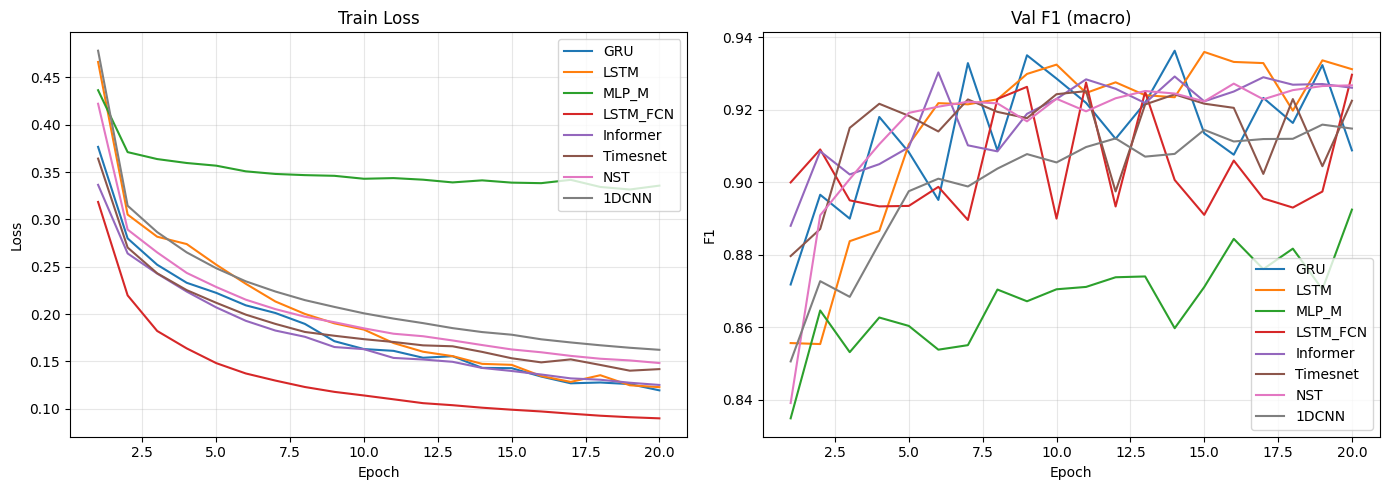

In [111]:
import json
import matplotlib.pyplot as plt
from pathlib import Path


def plot_training_curves(
    runs: dict,
    figsize: tuple = (14, 5),
    smooth: int = 1,
):
    """
    runs: {"GRU": "outputs/runs/SDAHU/gru_w100_s1_seed42", ...}
    smooth: скользящее среднее по эпохам (1 = без сглаживания)
    """
    def _smooth(values, k):
        if k <= 1:
            return values
        out = []
        for i in range(len(values)):
            start = max(0, i - k + 1)
            out.append(sum(values[start:i+1]) / (i - start + 1))
        return out

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    for name, run_dir in runs.items():
        history_path = Path(run_dir) / "history.json"
        if not history_path.exists():
            print(f"history.json не найден: {run_dir}")
            continue

        with open(history_path) as f:
            h = json.load(f)

        epochs = range(1, len(h["train_loss"]) + 1)

        train_loss = _smooth(h["train_loss"], smooth)
        ax1.plot(epochs, train_loss, label=name)

        # val_f1 — ключ может быть val_f1_macro или val_f1_weighted
        val_f1_key = next((k for k in h if k.startswith("val_f1")), None)
        if val_f1_key and h[val_f1_key]:
            val_f1 = _smooth(h[val_f1_key], smooth)
            ax2.plot(epochs, val_f1, label=name)

    ax1.set_title("Train Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.set_title("Val F1 (macro)")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("F1")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


# использование
runs = {
    "GRU":         "../outputs/runs/SDAHU_1/gru",
    "LSTM":        "../outputs/runs/SDAHU_1/lstm",
    "MLP_M":        "../outputs/runs/SDAHU_1/mlp_m",
    "LSTM_FCN": "../outputs/runs/SDAHU_1/lstm_fcn",
    "Informer": "../outputs/runs/SDAHU_1/informer",
    "Timesnet": "../outputs/runs/SDAHU_1/timesnet",
    "NST": "../outputs/runs/SDAHU_1/nonstationary_transformer",
    "1DCNN": "../outputs/runs/SDAHU_1/cnn1d"
}

fig = plot_training_curves(runs, smooth=1)
plt.savefig("training_curves.png", dpi=150)
plt.show()

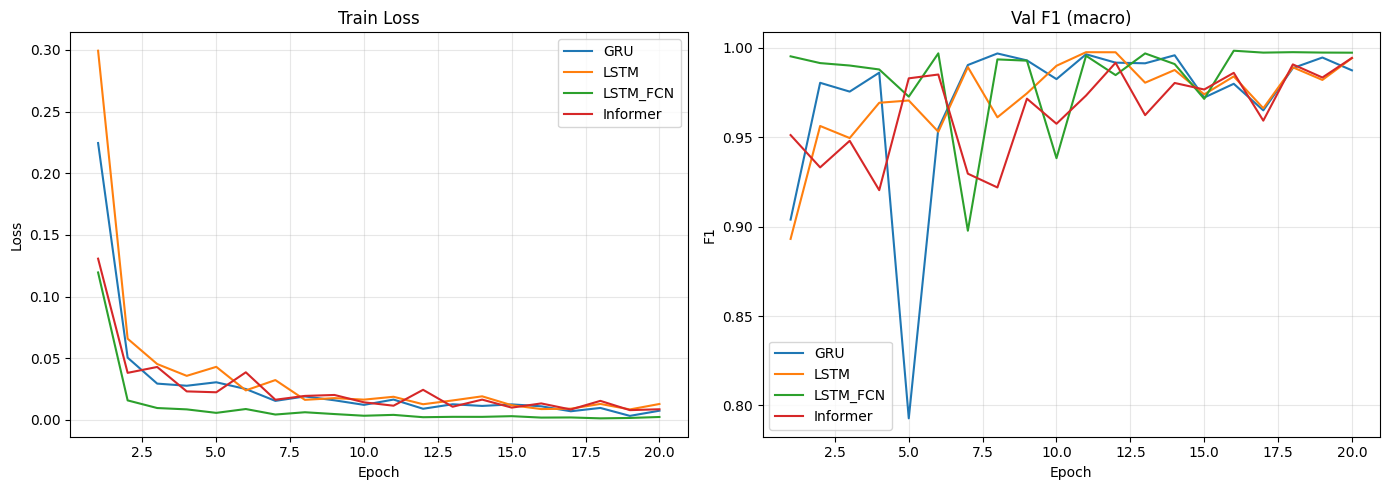

In [117]:
runs = {
    "GRU":         "../outputs/runs/Simulated_RTU_1/gru",
    "LSTM":        "../outputs/runs/Simulated_RTU_1/lstm",
    #"MLP_M":        "../outputs/runs/Simulated_RTU_1/mlp_m",
    "LSTM_FCN": "../outputs/runs/Simulated_RTU_1/lstm_fcn",
    "Informer": "../outputs/runs/Simulated_RTU_1/informer",
    #"Timesnet": "../outputs/runs/Simulated_RTU_1/timesnet",
    #"NST": "../outputs/runs/Simulated_RTU_1/nonstationary_transformer",
    #"1DCNN": "../outputs/runs/Simulated_RTU_1/cnn1d"
}

fig = plot_training_curves(runs, smooth=1)
plt.savefig("training_curves.png", dpi=150)
plt.show()

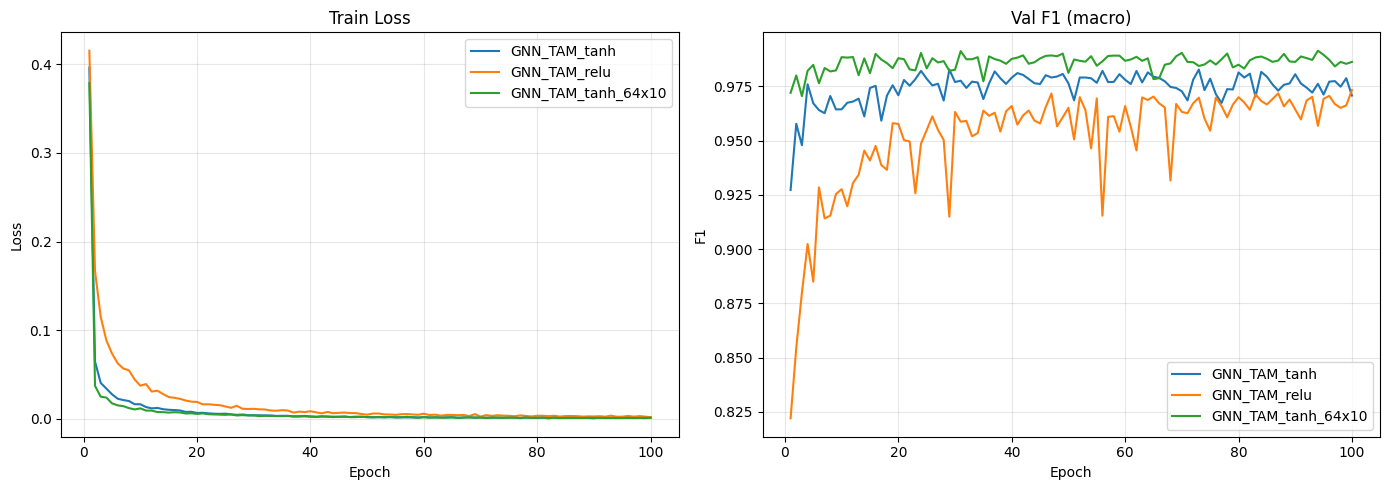

In [120]:
runs = {
    "GNN_TAM_tanh":         "../outputs/runs/Simulated_RTU_1/gnn_tam_tanh",
    "GNN_TAM_relu":        "../outputs/runs/Simulated_RTU_1/gnn_tam_relu",
    "GNN_TAM_tanh_64x10":        "../outputs/runs/Simulated_RTU_1/gnn_tam_tanh_64x10",
}

fig = plot_training_curves(runs, smooth=1)
plt.savefig("training_curves.png", dpi=150)
plt.show()

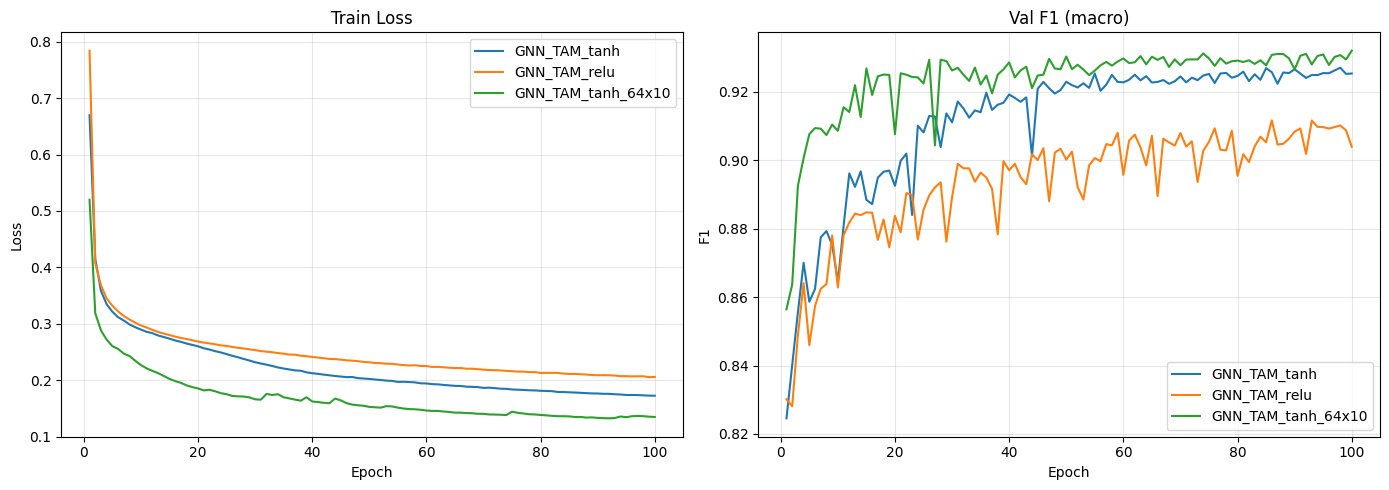

In [121]:
runs = {
    "GNN_TAM_tanh":         "../outputs/runs/SDAHU/gnn_tam_tanh",
    "GNN_TAM_relu":        "../outputs/runs/SDAHU/gnn_tam_relu",
    "GNN_TAM_tanh_64x10":        "../outputs/runs/SDAHU/gnn_tam_tanh_64x10",
}

fig = plot_training_curves(runs, smooth=1)
plt.savefig("training_curves.png", dpi=150)
plt.show()

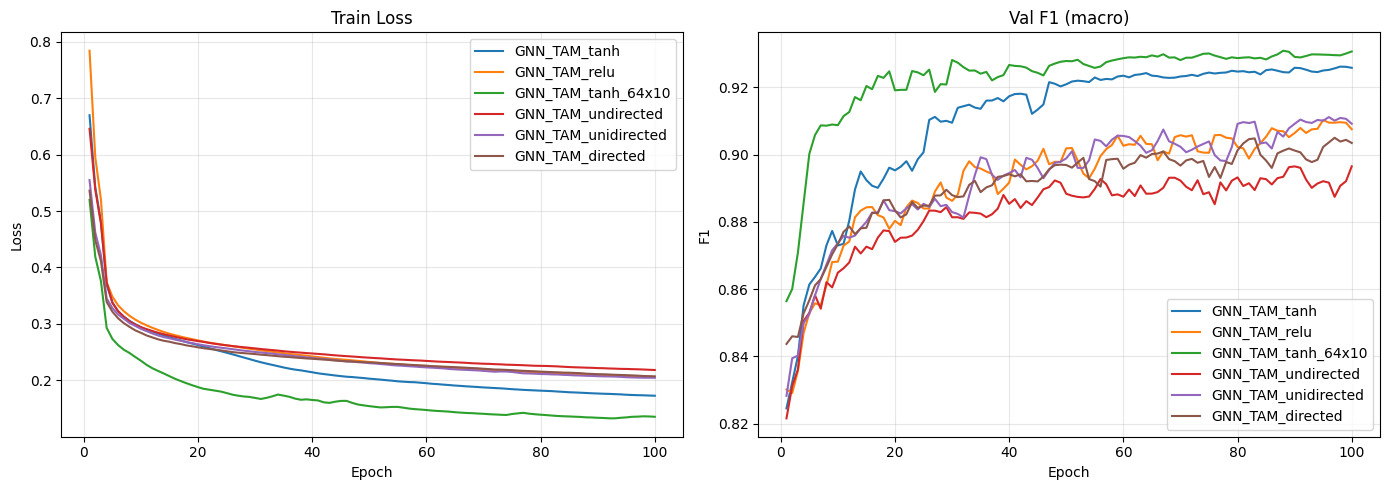

In [124]:
runs = {
    "GNN_TAM_tanh":         "../outputs/runs/SDAHU/gnn_tam_tanh",
    "GNN_TAM_relu":        "../outputs/runs/SDAHU/gnn_tam_relu",
    "GNN_TAM_tanh_64x10":        "../outputs/runs/SDAHU/gnn_tam_tanh_64x10",
    "GNN_TAM_undirected":        "../outputs/runs/SDAHU/gnn_tam_undirected",
    "GNN_TAM_unidirected":        "../outputs/runs/SDAHU/gnn_tam_unidirected",
    "GNN_TAM_directed":        "../outputs/runs/SDAHU/gnn_tam_directed",
}

fig = plot_training_curves(runs, smooth=3)
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [60]:
!pip install matplotlib seaborn

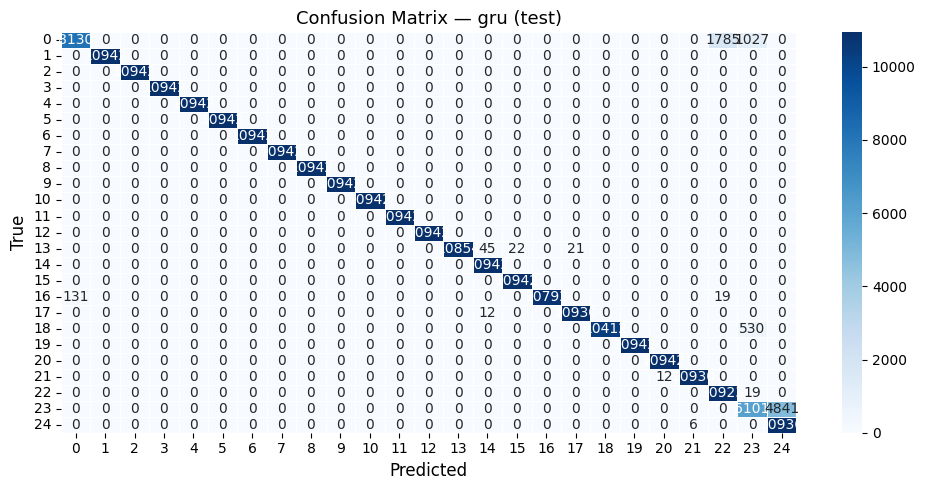

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from pathlib import Path

def plot_confusion_matrix(
    run_dir: str,
    split: str = "test",
    class_names: list = None,
    figsize: tuple = (10, 5),
    normalize: bool = True,
):
    run_dir = Path(run_dir)
    y_true = np.load(run_dir / f"{split}_y_true.npy")
    y_pred = np.load(run_dir / f"{split}_y_pred.npy")

    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
        vmax = 1.0
    else:
        fmt = "d"
        vmax = cm.max()

    n_classes = cm.shape[0]
    if class_names is None:
        class_names = [str(i) for i in range(n_classes)]

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        vmin=0,
        vmax=vmax,
        ax=ax,
        linewidths=0.5,
    )
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True", fontsize=12)
    ax.set_title(f"Confusion Matrix — {run_dir.name} ({split})", fontsize=13)
    plt.tight_layout()
    return fig


# использование
fig = plot_confusion_matrix(
    run_dir="../outputs/runs/Simulated_RTU_1/gru",
    split="test",
    normalize=False,
)
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

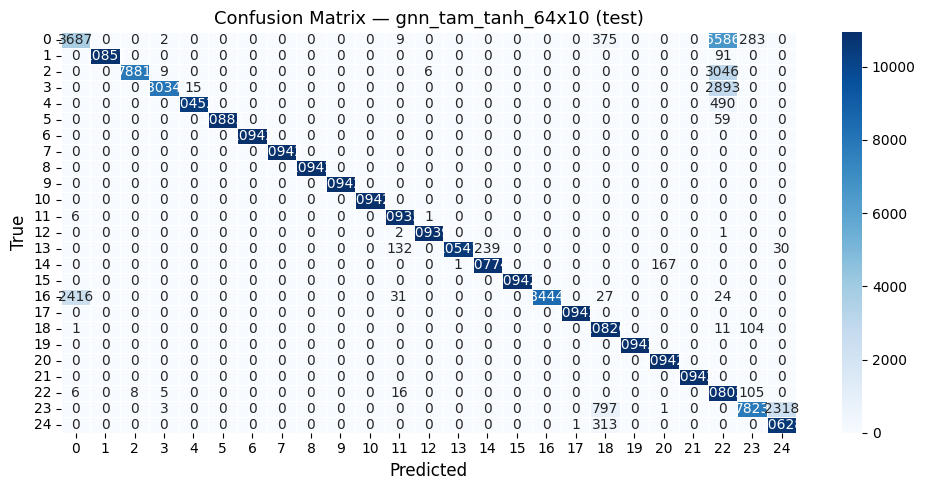

In [73]:
# использование
fig = plot_confusion_matrix(
    run_dir="../outputs/runs/Simulated_RTU/gnn_tam_tanh_64x10",
    split="test",
    normalize=False,
)
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

In [74]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from pathlib import Path


def class_metrics(run_dir: str, split: str = "test", class_names: list = None):
    run_dir = Path(run_dir)
    y_true = np.load(run_dir / f"{split}_y_true.npy")
    y_pred = np.load(run_dir / f"{split}_y_pred.npy")

    n_classes = len(np.unique(y_true))
    if class_names is None:
        class_names = [str(i) for i in range(n_classes)]

    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        output_dict=True,
    )

    df = pd.DataFrame(report).T
    df = df.drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore")
    df = df[["precision", "recall", "f1-score", "support"]]
    df["support"] = df["support"].astype(int)
    df = df.sort_values("f1-score", ascending=False)

    return df


# использование
df = class_metrics(
    run_dir="../outputs/runs/Simulated_RTU/gru",
    split="test",
)
print(df.to_string(float_format="{:.3f}".format))

    precision  recall  f1-score  support
12      1.000   1.000     1.000    10942
7       1.000   1.000     1.000    10942
19      1.000   1.000     1.000    10942
1       1.000   1.000     1.000    10942
10      1.000   1.000     1.000    10942
9       1.000   1.000     1.000    10942
8       1.000   1.000     1.000    10942
11      1.000   1.000     1.000    10942
6       1.000   1.000     1.000    10942
5       1.000   1.000     1.000    10942
4       1.000   1.000     1.000    10942
3       1.000   1.000     1.000    10942
2       1.000   1.000     1.000    10942
20      0.999   1.000     0.999    10942
21      0.999   0.999     0.999    10942
15      0.998   1.000     0.999    10942
17      0.998   0.999     0.998    10942
14      0.995   1.000     0.997    10942
13      1.000   0.992     0.996    10942
16      1.000   0.986     0.993    10942
18      1.000   0.952     0.975    10942
22      0.858   0.998     0.923    10942
0       0.984   0.743     0.847    10942
24      0.693   

In [76]:
# использование
df = class_metrics(
    run_dir="../outputs/runs/Simulated_RTU/gnn_tam_tanh_64x10",
    split="test",
)
print(df.to_string(float_format="{:.3f}".format))

    precision  recall  f1-score  support
9       1.000   1.000     1.000    10942
8       1.000   1.000     1.000    10942
21      1.000   1.000     1.000    10942
19      1.000   1.000     1.000    10942
15      1.000   1.000     1.000    10942
10      1.000   1.000     1.000    10942
6       1.000   1.000     1.000    10942
7       1.000   1.000     1.000    10942
17      1.000   1.000     1.000    10942
12      0.999   1.000     1.000    10942
5       1.000   0.995     0.997    10942
1       1.000   0.992     0.996    10942
20      0.985   1.000     0.992    10942
11      0.983   0.999     0.991    10942
14      0.978   0.985     0.981    10942
13      1.000   0.963     0.981    10942
4       0.999   0.955     0.976    10942
18      0.877   0.989     0.930    10942
24      0.819   0.971     0.889    10942
16      1.000   0.772     0.871    10942
3       0.998   0.734     0.846    10942
2       0.999   0.720     0.837    10942
23      0.941   0.715     0.812    10942
22      0.450   

In [23]:
import torch
ckpt = torch.load("../outputs/runs/Simulated_RTU/gru_w100_s1_seed42_no_concat_layers_2/best_model.pt", map_location="cpu")
print(ckpt["model_state_dict"]["linear1.weight"].shape)

torch.Size([128, 256])
